# Appstore music reviews EDA

#### pip install

In [61]:
pip install pandas numpy matplotlib seaborn emoji scikit-learn langdetect nltk wordcloud

Note: you may need to restart the kernel to use updated packages.


In [62]:
pip install langdetect emoji


Note: you may need to restart the kernel to use updated packages.


## Importing necessary Libraries

In [63]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns, datetime
import emoji
from IPython.display import display

from sklearn.feature_extraction.text import CountVectorizer
from langdetect import detect
from nltk.sentiment import SentimentIntensityAnalyzer
from collections import Counter
from wordcloud import WordCloud
import nltk

import warnings
warnings.filterwarnings('ignore')

nltk.download('vader_lexicon')

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     /home/athul_rohan/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


True

## Loading and Viewing the Dataset

In [64]:
# Read CSV and parse dates + set column(s) in correct dtype

data = pd.read_csv('./app_store_music_reviews.csv', parse_dates=['date']) # Parse dates in correct format
data['rating'] = data['rating'].astype(int) # Set Rating column to correct datatype
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 5640 entries, 0 to 5639
Data columns (total 6 columns):
 #   Column   Non-Null Count  Dtype                    
---  ------   --------------  -----                    
 0   app      5640 non-null   str                      
 1   country  5640 non-null   str                      
 2   title    5640 non-null   str                      
 3   review   5640 non-null   str                      
 4   rating   5640 non-null   int64                    
 5   date     5640 non-null   datetime64[us, UTC-07:00]
dtypes: datetime64[us, UTC-07:00](1), int64(1), str(4)
memory usage: 264.5 KB


In [65]:
data.head() # View first five rows

,app,country,title,review,rating,date
0,Spotify,MX,Muy buena aplicación de música. Casi sin anunc...,La,5,2025-05-21 18:57:56-07:00
1,SoundCloud,US,I have loved you from day 1 bi,"Nah fr tho, omm nothing but love for SoundClou...",5,2025-05-21 18:56:41-07:00
2,Spotify,MX,Los amo,Los amo,5,2025-05-21 18:56:12-07:00
3,Deezer,US,Must have a premium account to download music,I got this music app so I could download songs...,1,2025-05-21 18:50:34-07:00
4,Apple Music,US,4 star,I tunes don’t have all the songs like to liste...,4,2025-05-21 18:50:04-07:00


In [66]:
# Shape, size and column names in the dataset

data_shape = data.shape
data_size = data.size
data_columns = data.columns

print(f"The pandas dataframe has {data_shape[0]} rows and {data_shape[1]} columns")
print(f"That would be {data_size} cells")
print(f"These are the column headers in the dataframe:\n{data_columns}")


The pandas dataframe has 5640 rows and 6 columns
That would be 33840 cells
These are the column headers in the dataframe:
Index(['app', 'country', 'title', 'review', 'rating', 'date'], dtype='str')


#### Null count and percent

In [67]:
# Get null count and Percentage and create two different dataframes with them
data_missing_count = pd.DataFrame(data.isnull().sum(), columns=['null_count']).reset_index()
data_missing_percentage = pd.DataFrame(data.isnull().mean()*100, columns=['null_percentage']).reset_index()

# pd merge the two dataframes
data_null = pd.merge(
    data_missing_count,
    data_missing_percentage,
    how = 'left',
    on = "index"
)

# Print table with null value count and percentage
print(data_null)

# Delete previously used variables
del data_missing_count
del data_missing_percentage

     index  null_count  null_percentage
0      app           0              0.0
1  country           0              0.0
2    title           0              0.0
3   review           0              0.0
4   rating           0              0.0
5     date           0              0.0


#### Checking for Duplicates

In [68]:
data.duplicated().sum()

np.int64(0)

In [69]:
data[data.duplicated(keep=False)]

,app,country,title,review,rating,date


## Data preprocessing

In [70]:
# Create a new feature: review_length
data['review_length'] = data['review'].astype(str).apply(len)

In [71]:
# Creating new Year and Month columns

data['Year'] = data.date.dt.year
data['Month'] = data.date.dt.month_name()

In [72]:
# Initializes the analyzer. sia is a pretrained dictionary. It contains thousands of words that have been manually scored by people
sia = SentimentIntensityAnalyzer()

data['sentiment_score'] = data['review'].apply(lambda x: sia.polarity_scores(str(x))['compound'])

## Data visualization - EDA

In [73]:
# Setting a colour scheme for the ratings scale - 1 is Red and 5 is Green, everything else in-between
rating_colors = ["#CE0A0A", '#FF7F00', '#FFFF00', '#8BEE00', '#00AF00']

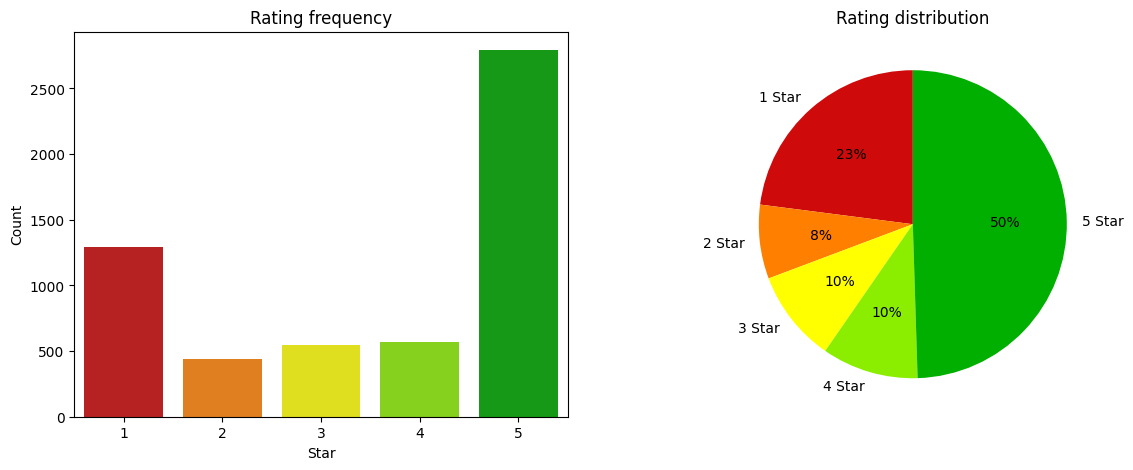

In [74]:
plt.figure(figsize=(14,5))

plt.subplot(1,2,1)
sns.countplot(
    data = data,
    x = 'rating',
    palette = rating_colors
);
plt.title('Rating frequency')
plt.xlabel('Star')
plt.ylabel('Count')

plt.subplot(1,2,2)
plt.pie(
    data= data,
    x = data.rating.value_counts().sort_index(ascending = True),
    colors = rating_colors,
    labels = ['1 Star','2 Star','3 Star','4 Star','5 Star'],
    autopct = '%0.f%%',
    startangle = 90
);
plt.title('Rating distribution')
plt.show()

In [75]:
table_app_rating = pd.crosstab(
    data['app'],
    data['rating']
)

table_app_rating.rename(columns = {
    1:'1 Star', 2:'2 Star', 3:'3 Star', 4:'4 Star', 5:'5 Star'
}, inplace = True)

table_app_rating

rating,1 Star,2 Star,3 Star,4 Star,5 Star
app,,,,,
Apple Music,168,56,86,113,577
Deezer,345,92,105,100,248
Shazam,212,50,54,50,634
SoundCloud,175,57,84,98,586
Spotify,235,71,92,81,471
TIDAL,160,112,123,129,276


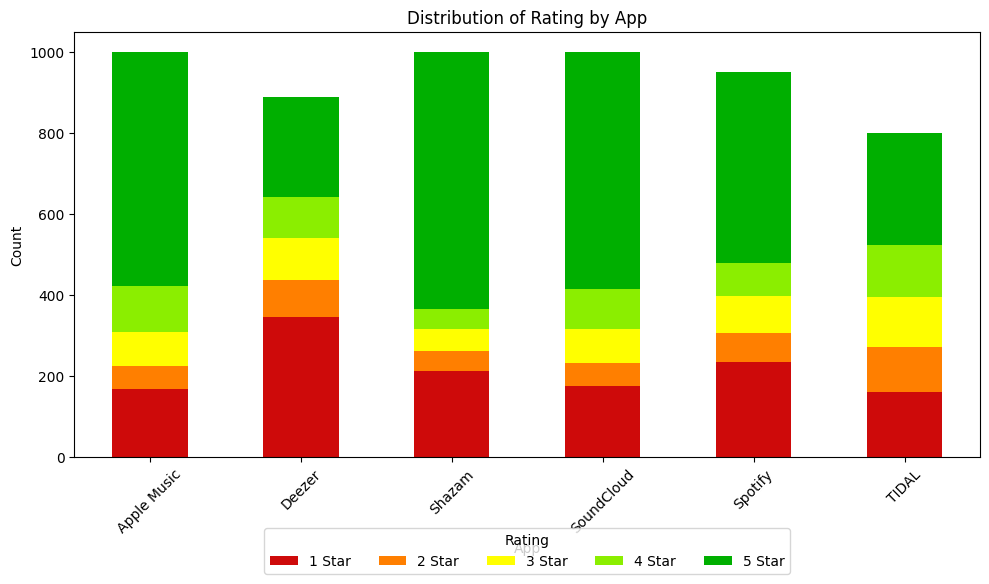

In [76]:
table_app_rating.plot(
    kind = 'bar',
    stacked = True,
    figsize = (10,6),
    color = rating_colors
);

plt.legend(
    title='Rating', 
    loc='upper center', 
    bbox_to_anchor=(0.5, -0.15), # Move legend below the x-axis
    ncol=5                       # Forces labels into single line (5 columns is the logic)
)

plt.title("Distribution of Rating by App")
plt.xlabel('App')
plt.xticks(rotation=45)
plt.ylabel('Count')

plt.tight_layout()
plt.show()

In [77]:
data.country.value_counts().reset_index()

,country,count
0,MX,300
1,US,300
2,CA,300
3,BR,300
4,FR,300
5,GB,300
6,AU,300
7,DE,300
8,IT,300
9,NL,300


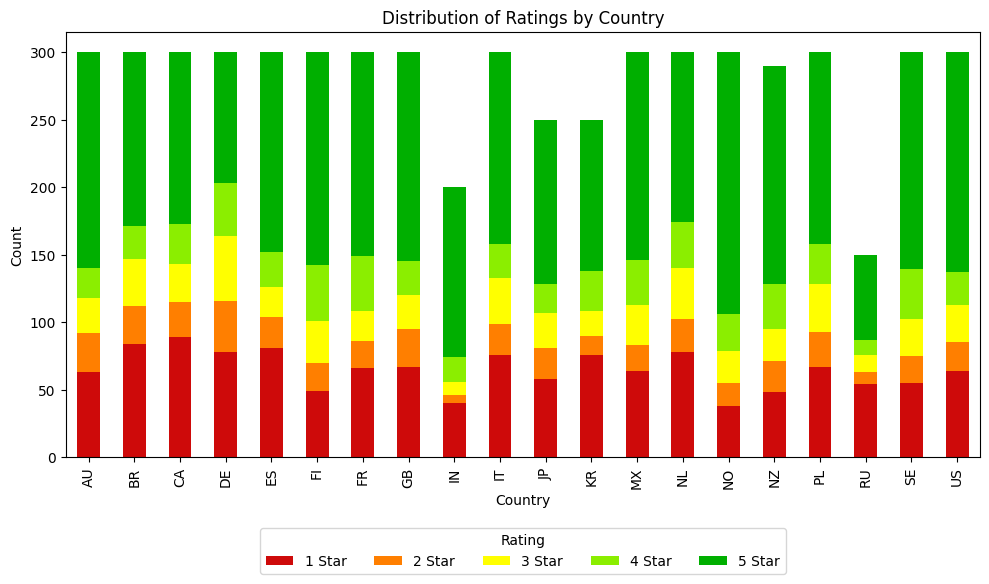

In [78]:
# Plotting a graph using a crosstab

# Crosstab sort - country and ratings
table_country_rating = pd.crosstab(
    data['country'],
    data['rating']
)

# Rename column headers
table_country_rating.rename(
    columns = {1:'1 Star', 2:'2 Star', 3:'3 Star', 4:'4 Star', 5:'5 Star'},
    inplace = True
)

# Plot using crosstab
table_country_rating.plot(
    kind = "bar",
    stacked = True,
    figsize = (10,6),
    color = rating_colors
)

plt.legend(
    title='Rating', 
    loc='upper center', 
    bbox_to_anchor=(0.5, -0.15), # Move legend below the x-axis
    ncol=5                       # Forces labels into single line (5 columns is the logic)
)

plt.title("Distribution of Ratings by Country")
plt.xlabel("Country")
plt.ylabel("Count")

plt.tight_layout()
plt.show();

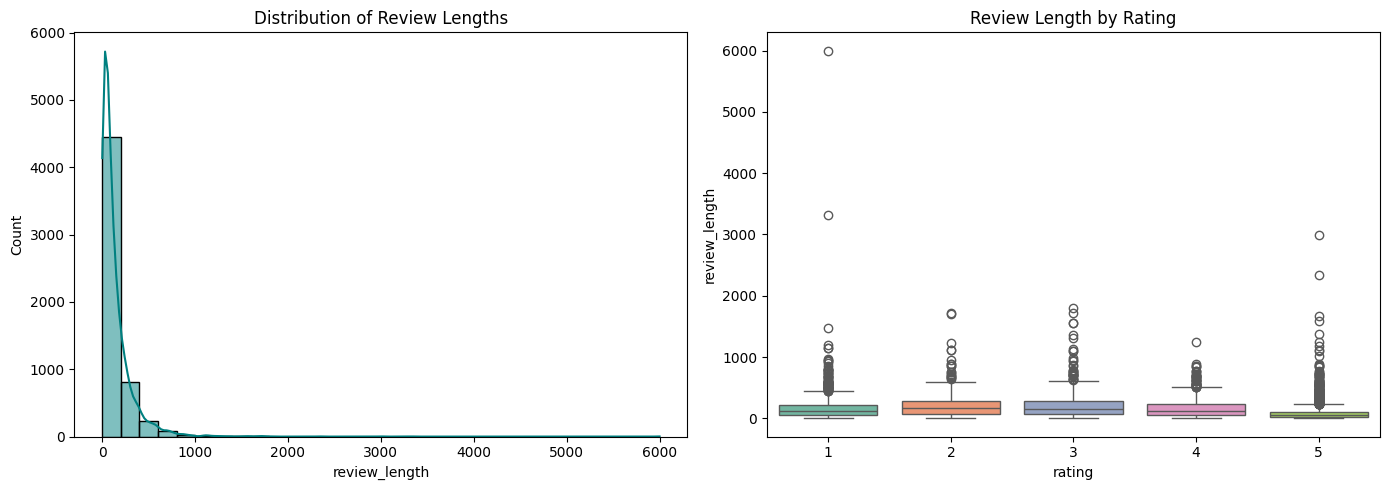

In [79]:
plt.figure(figsize=(14,5))

# LHS plot
plt.subplot(1,2,1)
sns.histplot(data['review_length'], bins=30, kde=True, color='teal')
plt.title('Distribution of Review Lengths')

# RHS plot
plt.subplot(1,2,2)
sns.boxplot(data, x = 'rating', y = 'review_length', palette='Set2')
plt.title('Review Length by Rating')


plt.tight_layout()
plt.show();

## Sentiment analysis

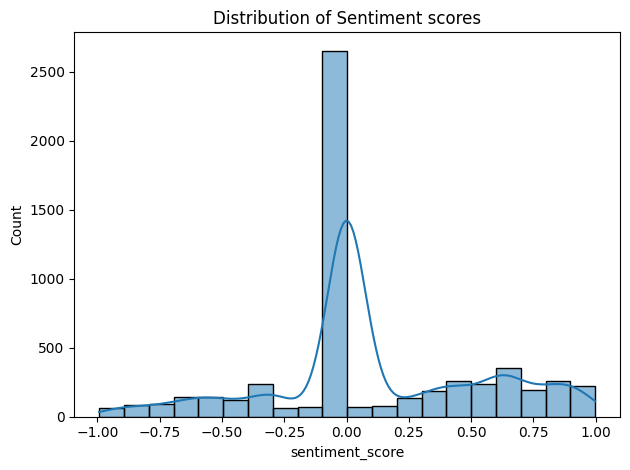

In [80]:
# Distribution of sentiment scores

sns.histplot(
    data["sentiment_score"],
    bins = 20,
    kde = True
)

plt.title("Distribution of Sentiment scores")

plt.tight_layout()
plt.show();

In [81]:
# Searching for reviews where rating is 5 but Sentiment is less than -0.5
contradictory_filter = (data['rating'] == 5) & (data['sentiment_score'] < -0.5)
contradictory_reviews = data[contradictory_filter]

# Sorting to see worst reviews first
contradictory_reviews = contradictory_reviews.sort_values(by='sentiment_score')

contradictory_reviews[['review', 'rating', 'sentiment_score']].head(15)

,review,rating,sentiment_score
3401,Ich finde die App super. Man kann gut Musik hö...,5,-0.9623
2004,Die App ist wirklich toll. Es wird auch genau ...,5,-0.9524
3676,Als großer Musikfreak habe ich in den letzten ...,5,-0.9508
4045,"Ich liebe die app sehr, nur die Such Funktion ...",5,-0.9280
1814,"Apple Musik ist genial, lossless über Kabel be...",5,-0.9165
3189,"De verdad no es para exagerar, pero esta aplic...",5,-0.8910
248,Spotify leistet hervorragende Arbeit vor allem...,5,-0.8439
777,If you have spotify premium is super good. But...,5,-0.8396
2268,Ich ich folge dem Ren auf seinem YouTube Kanal...,5,-0.8316
3222,"Ich nutze die App schon sehr lange, leider ist...",5,-0.8316


In [82]:
# Searching for reviews where rating is 1 but Sentiment is greated than 0.5
happy_complaints_filter = (data['rating'] == 1) & (data['sentiment_score'] > 0.5)
happy_complaints_review = data[happy_complaints_filter]

# Sorting to see worst reviews first
happy_complaints_review = happy_complaints_review.sort_values(by='sentiment_score')

happy_complaints_review[['review', 'rating', 'sentiment_score']].head(15)

,review,rating,sentiment_score
1105,Per quanto mi piacerebbe impostare STATI UNITI...,1,0.5067
111,You have enough people buying your service... ...,1,0.5106
2496,Sempre utilizei o Deezer premium pela oferta d...,1,0.5106
2037,Make ts free bru 🥀🥀🥀🪫🪫💔,1,0.5106
5296,"pessimo, ho fatto l’abbonamento ma mi dice che...",1,0.5106
5189,Premetto che non sono un assiduo utilizzatore ...,1,0.5106
5099,Era ottima ma la versione free in Italia non è...,1,0.5106
4360,I’ve been with Tidal for around 7 years now an...,1,0.5187
2166,Why in the latest update you have added a ”+ c...,1,0.5204
4987,I rarely experienced a poor customer service t...,1,0.5237
